In [60]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Task 4 - Sentiment Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

print("Libraries imported successfully!")

/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_validation.csv
/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv
Libraries imported successfully!


In [61]:
# Load the dataset

train_path = "/kaggle/input/datasets/jp797498e/twitter-entity-sentiment-analysis/twitter_training.csv"

df = pd.read_csv(
    train_path,
    header=None,
    names=["Tweet ID", "entity", "sentiment", "Tweet content"]
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (74682, 4)


,Tweet ID,entity,sentiment,Tweet content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [62]:
# Inspect the dataset

print("Dataset Information:")
print(df.info())

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet ID       74682 non-null  int64 
 1   entity         74682 non-null  object
 2   sentiment      74682 non-null  object
 3   Tweet content  73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None

First 5 rows:


,Tweet ID,entity,sentiment,Tweet content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...



Dataset shape:
(74682, 4)

Column names:
['Tweet ID', 'entity', 'sentiment', 'Tweet content']


In [63]:
# Check missing values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Tweet ID           0
entity             0
sentiment          0
Tweet content    686
dtype: int64


In [64]:
# Check sentiment categories and their counts

print("Unique sentiment labels:")
print(df["sentiment"].unique())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Unique sentiment labels:
['Positive' 'Neutral' 'Negative' 'Irrelevant']

Sentiment distribution:
sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


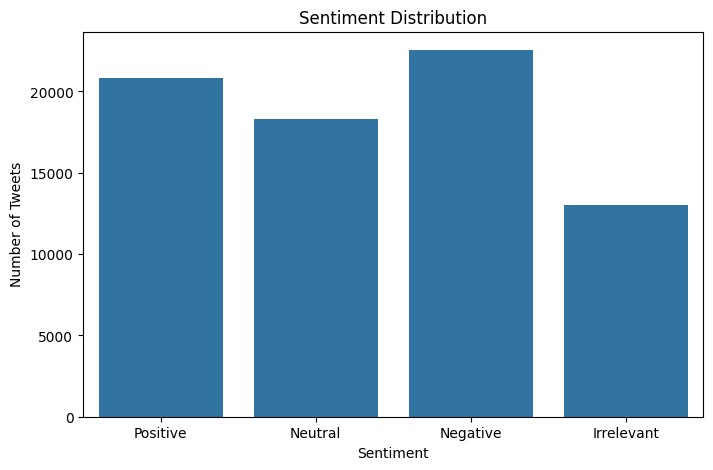

In [65]:
# Visualize sentiment distribution

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

In [66]:
# Remove Irrelevant sentiment

df = df[df["sentiment"].isin(["Positive", "Negative", "Neutral"])].copy()

print("Sentiment distribution after removing Irrelevant:")
print(df["sentiment"].value_counts())

Sentiment distribution after removing Irrelevant:
sentiment
Negative    22542
Positive    20832
Neutral     18318
Name: count, dtype: int64


In [67]:
# Remove rows with missing tweet content

df = df.dropna(subset=["Tweet content"]).copy()

print("Final dataset shape:", df.shape)
print("\nMissing Tweet content:")
print(df["Tweet content"].isnull().sum())

Final dataset shape: (61121, 4)

Missing Tweet content:
0


In [68]:
# Display cleaned dataset

display(df.head())

print("\nFinal sentiment distribution:")
print(df["sentiment"].value_counts())

,Tweet ID,entity,sentiment,Tweet content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...



Final sentiment distribution:
sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64


In [69]:
# Text preprocessing

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

stop_words = set(ENGLISH_STOP_WORDS)

def clean_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # Remove user mentions
    text = re.sub(r"@\w+", "", text)
    
    # Remove hashtags
    text = re.sub(r"#\w+", "", text)
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()
    
    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    
    return " ".join(words)

df["clean_text"] = df["Tweet content"].apply(clean_text)

display(df[["Tweet content", "clean_text"]].head())

,Tweet content,clean_text
0,im getting on borderlands and i will murder yo...,im getting borderlands murder
1,I am coming to the borders and I will kill you...,coming borders kill
2,im getting on borderlands and i will kill you ...,im getting borderlands kill
3,im coming on borderlands and i will murder you...,im coming borderlands murder
4,im getting on borderlands 2 and i will murder ...,im getting borderlands murder


## Text Preprocessing

The tweet text was cleaned before applying machine learning.

The preprocessing steps included:

- Converting text to lowercase
- Removing URLs
- Removing user mentions
- Removing hashtags
- Removing numbers
- Removing punctuation and special characters
- Removing extra whitespace
- Removing common English stopwords

The cleaned text was then used for TF-IDF feature extraction.

In [70]:
# Separate features and target

X = df["clean_text"]
y = df["sentiment"]

# Split into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 48896
Testing samples: 12225


In [71]:
# TF-IDF feature extraction

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (48896, 5000)
Testing TF-IDF shape: (12225, 5000)


## TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical features that machine learning models can understand.

It gives higher importance to words that are useful for distinguishing tweets while reducing the importance of very common words.

For this project, the TF-IDF vectorizer generated 5,000 features from the cleaned tweets.

In [72]:
# Train Multinomial Naive Bayes

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred, average="weighted"))
print("Recall   :", recall_score(y_test, nb_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, nb_pred, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, nb_pred))

Naive Bayes Results
-------------------
Accuracy : 0.7033946830265849
Precision: 0.7073214413523089
Recall   : 0.7033946830265849
F1 Score : 0.6986556857231361

Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.81      0.74      4472
     Neutral       0.74      0.54      0.62      3622
    Positive       0.71      0.73      0.72      4131

    accuracy                           0.70     12225
   macro avg       0.71      0.69      0.69     12225
weighted avg       0.71      0.70      0.70     12225



In [73]:
# Train Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred, average="weighted"))
print("Recall   :", recall_score(y_test, lr_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, lr_pred, average="weighted"))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Results
---------------------------
Accuracy : 0.7498568507157464
Precision: 0.7500763702468657
Recall   : 0.7498568507157464
F1 Score : 0.7482977485163395

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.82      0.78      4472
     Neutral       0.74      0.65      0.69      3622
    Positive       0.77      0.76      0.76      4131

    accuracy                           0.75     12225
   macro avg       0.75      0.74      0.75     12225
weighted avg       0.75      0.75      0.75     12225



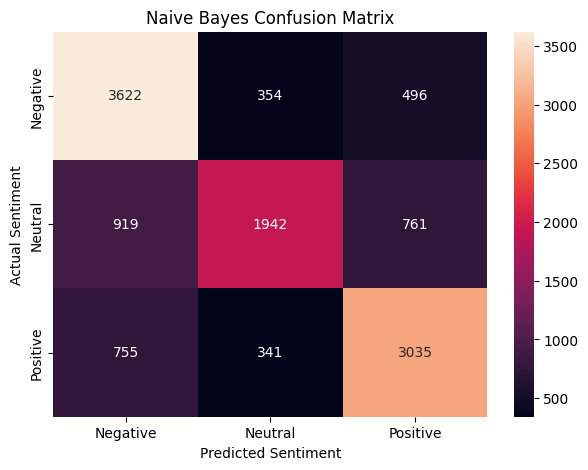

In [74]:
# Naive Bayes Confusion Matrix

cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

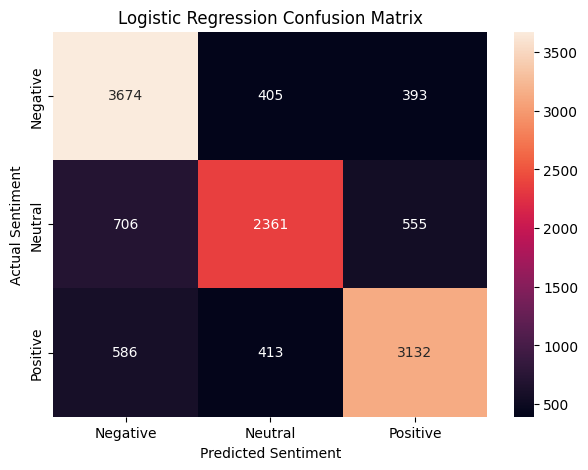

In [75]:
# Logistic Regression Confusion Matrix

cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Neutral", "Positive"],
    yticklabels=["Negative", "Neutral", "Positive"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.show()

In [76]:
# Model comparison

results = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred, average="weighted"),
        precision_score(y_test, lr_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, nb_pred, average="weighted"),
        recall_score(y_test, lr_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, nb_pred, average="weighted"),
        f1_score(y_test, lr_pred, average="weighted")
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.7034,0.7073,0.7034,0.6987
1,Logistic Regression,0.7499,0.7501,0.7499,0.7483


## Model Comparison

Two machine learning models were trained and evaluated for sentiment classification: Multinomial Naive Bayes and Logistic Regression.

The model comparison above shows the Accuracy, Precision, Recall, and F1-score for both classifiers.

The model with the highest overall performance was selected as the better model for this sentiment classification task.

In [77]:
from wordcloud import WordCloud

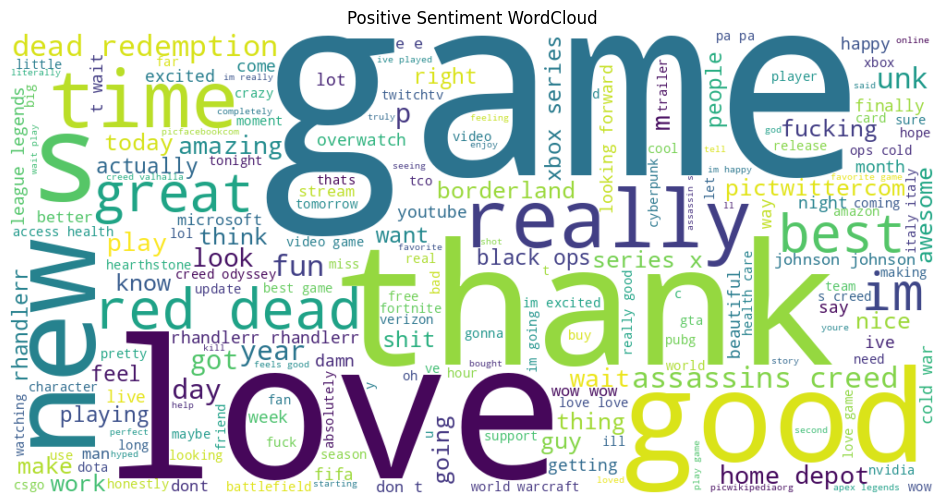

In [78]:
# Positive Sentiment WordCloud

positive_text = " ".join(
    df[df["sentiment"] == "Positive"]["clean_text"]
)

wordcloud_positive = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_positive, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Sentiment WordCloud")
plt.show()

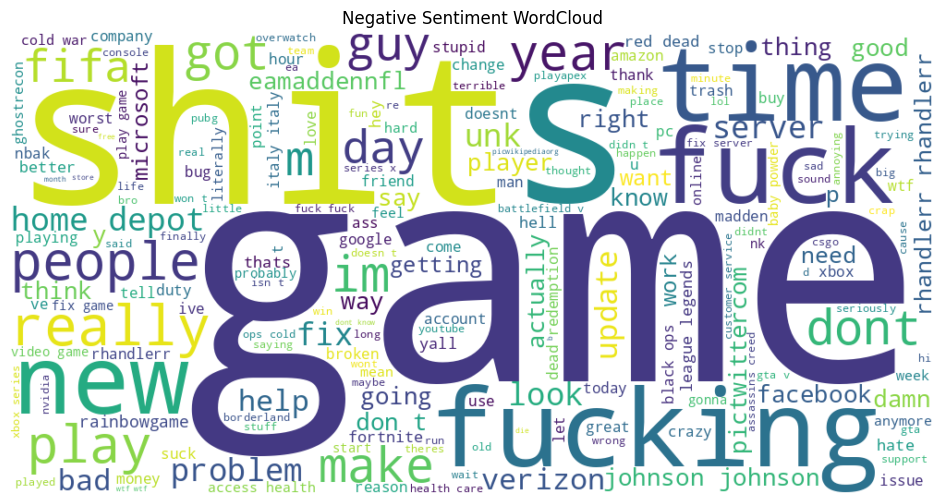

In [79]:
# Negative Sentiment WordCloud

negative_text = " ".join(
    df[df["sentiment"] == "Negative"]["clean_text"]
)

wordcloud_negative = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_negative, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Sentiment WordCloud")
plt.show()

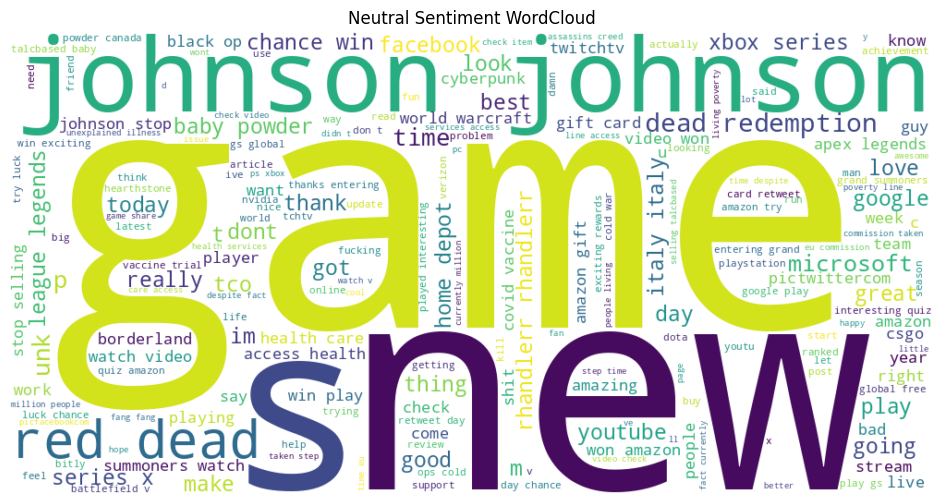

In [80]:
# Neutral Sentiment WordCloud

neutral_text = " ".join(
    df[df["sentiment"] == "Neutral"]["clean_text"]
)

wordcloud_neutral = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(neutral_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_neutral, interpolation="bilinear")
plt.axis("off")
plt.title("Neutral Sentiment WordCloud")
plt.show()

In [81]:
# Test the trained model with new tweets

sample_texts = [
    "I absolutely love this product!",
    "This is the worst experience ever.",
    "The product arrived today.",
    "Amazing service and very helpful staff!",
    "I am disappointed with the quality."
]

# Convert the new tweets using the same TF-IDF vectorizer
sample_tfidf = tfidf.transform(sample_texts)

# Predict sentiment
sample_predictions = lr_model.predict(sample_tfidf)

for text, prediction in zip(sample_texts, sample_predictions):
    print("Tweet:", text)
    print("Predicted sentiment:", prediction)
    print("-" * 50)

Tweet: I absolutely love this product!
Predicted sentiment: Positive
--------------------------------------------------
Tweet: This is the worst experience ever.
Predicted sentiment: Negative
--------------------------------------------------
Tweet: The product arrived today.
Predicted sentiment: Positive
--------------------------------------------------
Tweet: Amazing service and very helpful staff!
Predicted sentiment: Positive
--------------------------------------------------
Tweet: I am disappointed with the quality.
Predicted sentiment: Negative
--------------------------------------------------


In [82]:
# Final model comparison

comparison = pd.DataFrame({
    "Model": ["Multinomial Naive Bayes", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ],
    "Precision": [
        precision_score(y_test, nb_pred, average="weighted"),
        precision_score(y_test, lr_pred, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, nb_pred, average="weighted"),
        recall_score(y_test, lr_pred, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, nb_pred, average="weighted"),
        f1_score(y_test, lr_pred, average="weighted")
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.7034,0.7073,0.7034,0.6987
1,Logistic Regression,0.7499,0.7501,0.7499,0.7483


## Model Comparison

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Multinomial Naive Bayes | 70.34% | 70.73% | 70.34% | 69.87% |
| **Logistic Regression** | **74.99%** | **75.01%** | **74.99%** | **74.83%** |

**Logistic Regression achieved the best overall performance and was selected as the better-performing model.**

In [83]:
# Error Analysis: 5 misclassified examples

# Find incorrectly classified tweets
misclassified = df.loc[X_test.index].copy()
misclassified["Actual"] = y_test
misclassified["Predicted"] = lr_pred

# Keep only incorrect predictions
misclassified = misclassified[
    misclassified["Actual"] != misclassified["Predicted"]
]

# Display 5 misclassified examples
display(
    misclassified[
        ["Tweet content", "Actual", "Predicted"]
    ].head(5)
)

,Tweet content,Actual,Predicted
74489,Nvidia’s next Tesla GPUs could be 75% flat – g...,Neutral,Positive
28622,Whoa.,Positive,Negative
69616,And this is fire,Positive,Negative
42299,How did i become so depressed.. i only went th...,Neutral,Negative
49832,"Watching the streamers tear the bags, build th...",Positive,Negative


## Error Analysis

The following five examples were incorrectly classified by the Logistic Regression model:

1. **"Nvidia’s next Tesla GPUs could be 75% flat – ..."**  
   - Actual: Neutral
   - Predicted: Positive
   - The tweet contains technology-related information that may include positive-sounding words, making the sentiment difficult to determine.

2. **"Whoa."**
   - Actual: Positive
   - Predicted: Negative
   - This is a very short expression with little context. The model does not have enough information to understand the intended positive meaning.

3. **"And this is fire"**
   - Actual: Positive
   - Predicted: Negative
   - The word "fire" is used as slang to mean something impressive or excellent, but the model may interpret it differently because TF-IDF mainly learns word patterns rather than context.

4. **"How did i become so depressed.. i only went th..."**
   - Actual: Neutral
   - Predicted: Negative
   - The word "depressed" strongly indicates negative sentiment to the model, although the original dataset labels this tweet as neutral.

5. **"Watching the streamers tear the bags, build th..."**
   - Actual: Positive
   - Predicted: Negative
   - The wording contains terms that may appear in negative contexts, causing the model to associate the tweet with negative sentiment despite its positive label.

These errors show that sentiment classification can be challenging when tweets are very short, contain slang, or require contextual understanding. TF-IDF and Logistic Regression mainly rely on learned word patterns and therefore may struggle with sarcasm, slang, ambiguity, and context-dependent expressions.

## Conclusion

This project developed a machine learning-based sentiment analysis system using Twitter data.

The tweets were cleaned and preprocessed before being converted into numerical features using TF-IDF. Two classification algorithms, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated.

The models were evaluated using Accuracy, Precision, Recall, and F1-score. Confusion matrices and WordClouds were also used to analyze the model performance and sentiment patterns.

The better-performing model can be used for applications such as social media monitoring, customer feedback analysis, product review analysis, and customer satisfaction analysis.

The sample predictions demonstrate that the trained model can classify the sentiment of previously unseen tweets.